# RAG Pipelines - Data Ingestion to VectorDB Pipeline

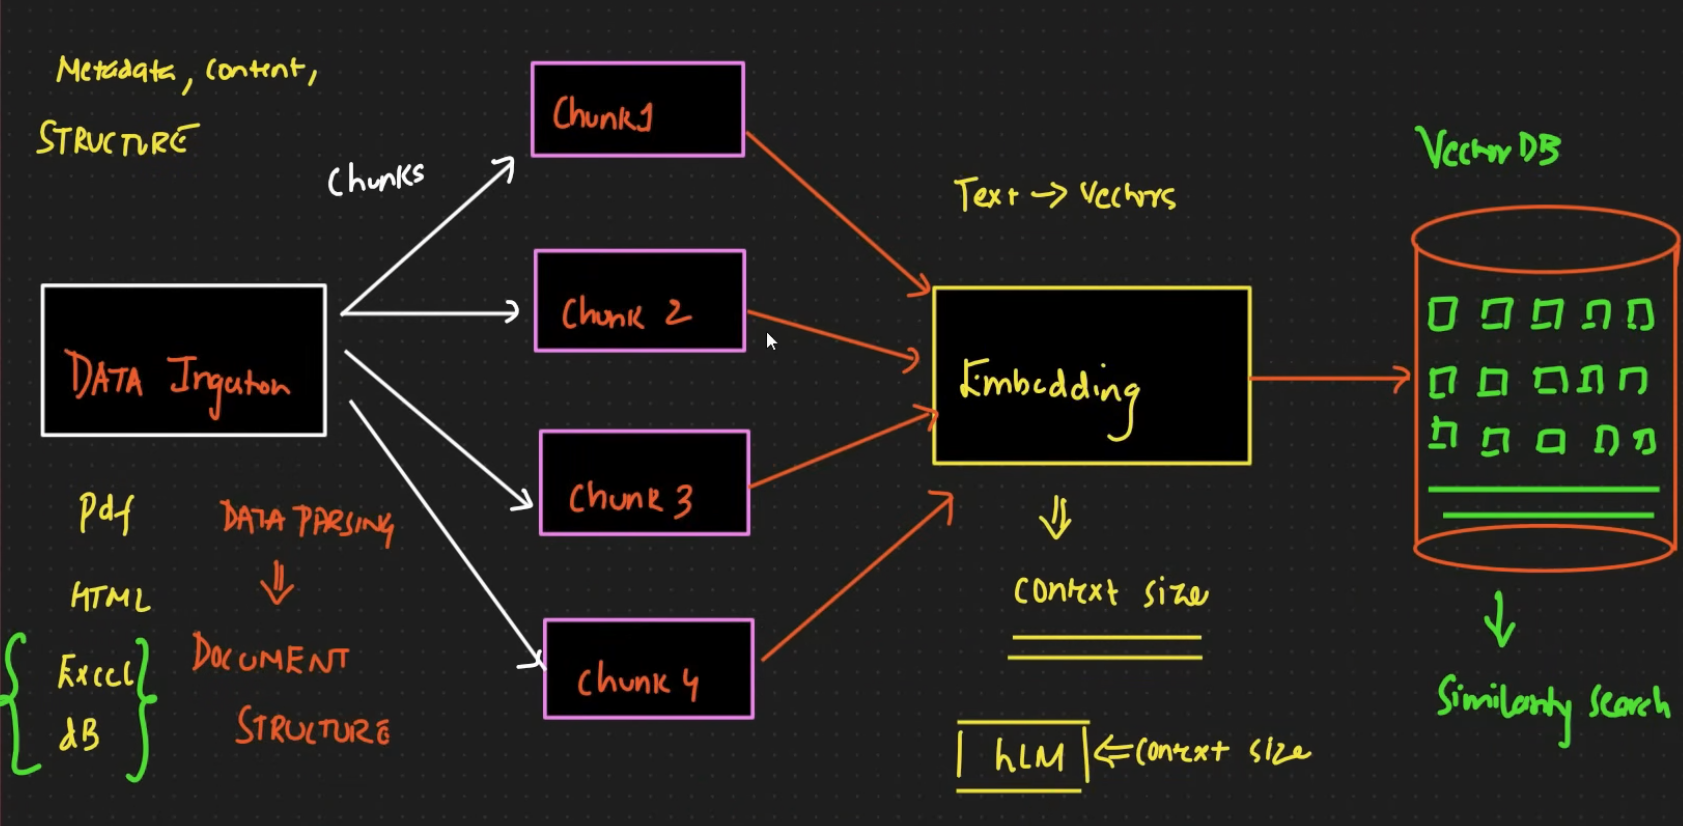

| Splitter                       | Splits by                              | Preserves meaning | Speed | Best use case                                                                       |
| ------------------------------ | -------------------------------------- | ----------------- | ----- | ----------------------------------------------------------------------------------- |
| CharacterTextSplitter          | Characters                             | ❌                 | ⭐⭐⭐⭐⭐ | Rarely used; simple text splitting                                                  |
| RecursiveCharacterTextSplitter | Characters with intelligent separators | ✅                 | ⭐⭐⭐⭐  | General-purpose RAG (recommended default)                                           |
| TokenTextSplitter              | Tokens                                 | ⚠️ Partial        | ⭐⭐⭐   | When you need precise control over model token limits                               |
| SemanticChunker                | Semantic similarity (embeddings)       | ⭐⭐⭐⭐⭐             | ⭐     | High-quality RAG where retrieval accuracy is more important than preprocessing time |


In [2]:
import os
from langchain_community.document_loaders import PyPDFLoader, PyMuPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from pathlib import Path

## Data Ingestion

In [3]:
BASE_DIR = "langgraph/4-RAG/data"

In [4]:
### Read all the pdf's inside the directory
def process_all_pdfs(pdf_directory):
    """Process all PDF files in a directory"""
    all_documents = []
    pdf_dir = Path(pdf_directory)
    
    # Find all PDF files recursively
    pdf_files = list(pdf_dir.glob("**/*.pdf"))
    
    print(f"Found {len(pdf_files)} PDF files to process")
    
    for pdf_file in pdf_files:
        print(f"\nProcessing: {pdf_file.name}")
        try:
            loader = PyPDFLoader(str(pdf_file))
            documents = loader.load()
            
            # Add source information to metadata
            for doc in documents:
                doc.metadata['source_file'] = pdf_file.name
                doc.metadata['file_type'] = 'pdf'
            
            all_documents.extend(documents)
            print(f"  ✓ Loaded {len(documents)} pages")
            
        except Exception as e:
            print(f"  ✗ Error: {e}")
    
    print(f"\nTotal documents loaded: {len(all_documents)}")
    return all_documents

# Process all PDFs in the data directory
all_pdf_documents = process_all_pdfs(BASE_DIR)

Found 2 PDF files to process

Processing: Demo_01_Building_an_RAG_Powered_FAQ_Agent_with_Custom_Knowledge.pdf
  ✓ Loaded 10 pages

Processing: Demo_02_Building_a_Finance_Q&A_Agent_Using_LangChain.pdf
  ✓ Loaded 7 pages

Total documents loaded: 17


In [5]:
all_pdf_documents

[Document(metadata={'producer': 'PyPDF', 'creator': 'Microsoft Word', 'creationdate': '2026-03-25T02:27:45-07:00', 'author': 'Md Azlaan Barkat', 'moddate': '2026-03-25T02:27:45-07:00', 'source': 'langgraph/4-RAG/data/pdf/Demo_01_Building_an_RAG_Powered_FAQ_Agent_with_Custom_Knowledge.pdf', 'total_pages': 10, 'page': 0, 'page_label': '1', 'source_file': 'Demo_01_Building_an_RAG_Powered_FAQ_Agent_with_Custom_Knowledge.pdf', 'file_type': 'pdf'}, page_content='Lesson 02 Demo 01 \n \nBuilding an RAG-Powered FAQ Agent with Custom Knowledge \n \nObjective: To build an RAG-powered FAQ agent using LangChain, FAISS, and an LLM that \nretrieves relevant document chunks and generates grounded, source-backed answers to \nsolve ungrounded or inconsistent responses and speed up accurate support \n \nTools required: Python, LangChain, FAISS, Azure OpenAI API, and Visual Studio Code \n \nPrerequisites: Familiarity with LangChain and RAG concepts \n \nSteps to be followed: \n1. Set up your local environ

## TextSplitting get into Chunks

In [6]:
def split_documents(documents, chunk_size = 1000, chunk_overlap = 200):
    """Split documents into smaller chunks for better RAG Performance"""
    text_splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap,
        length_function=len,
        separators=["\n\n", "\n", " ", ""]
    )

    split_docs = text_splitter.split_documents(documents=documents)
    print(f"Split {len(documents)} documents into {len(split_docs)} chunks")

    ## Example of chunking
    if split_docs:
        print(f"\n Example chunk:")
        print(f"\n Content: {split_docs[0].page_content[:200]}...")
        print(f"\n Metadata: {split_docs[0].metadata}...")

    return split_docs

In [7]:
chunks = split_documents(all_pdf_documents)
chunks

Split 17 documents into 19 chunks

 Example chunk:

 Content: Lesson 02 Demo 01 
 
Building an RAG-Powered FAQ Agent with Custom Knowledge 
 
Objective: To build an RAG-powered FAQ agent using LangChain, FAISS, and an LLM that 
retrieves relevant document chunks...

 Metadata: {'producer': 'PyPDF', 'creator': 'Microsoft Word', 'creationdate': '2026-03-25T02:27:45-07:00', 'author': 'Md Azlaan Barkat', 'moddate': '2026-03-25T02:27:45-07:00', 'source': 'langgraph/4-RAG/data/pdf/Demo_01_Building_an_RAG_Powered_FAQ_Agent_with_Custom_Knowledge.pdf', 'total_pages': 10, 'page': 0, 'page_label': '1', 'source_file': 'Demo_01_Building_an_RAG_Powered_FAQ_Agent_with_Custom_Knowledge.pdf', 'file_type': 'pdf'}...


[Document(metadata={'producer': 'PyPDF', 'creator': 'Microsoft Word', 'creationdate': '2026-03-25T02:27:45-07:00', 'author': 'Md Azlaan Barkat', 'moddate': '2026-03-25T02:27:45-07:00', 'source': 'langgraph/4-RAG/data/pdf/Demo_01_Building_an_RAG_Powered_FAQ_Agent_with_Custom_Knowledge.pdf', 'total_pages': 10, 'page': 0, 'page_label': '1', 'source_file': 'Demo_01_Building_an_RAG_Powered_FAQ_Agent_with_Custom_Knowledge.pdf', 'file_type': 'pdf'}, page_content='Lesson 02 Demo 01 \n \nBuilding an RAG-Powered FAQ Agent with Custom Knowledge \n \nObjective: To build an RAG-powered FAQ agent using LangChain, FAISS, and an LLM that \nretrieves relevant document chunks and generates grounded, source-backed answers to \nsolve ungrounded or inconsistent responses and speed up accurate support \n \nTools required: Python, LangChain, FAISS, Azure OpenAI API, and Visual Studio Code \n \nPrerequisites: Familiarity with LangChain and RAG concepts \n \nSteps to be followed: \n1. Set up your local environ

## Embeddings (Converting Text to Vectors)

In [8]:
import numpy as np
from sentence_transformers import SentenceTransformer ####----> Is Embedding Model
import chromadb
import uuid
from chromadb.config import Settings 
from typing import List, Dict, Any, Tuple
from sklearn.metrics.pairwise import cosine_similarity

In [9]:
## Modular coding

class EmbeddingManager:
    """Handles document embedding generation using SentenceTransformer"""

    def __init__(self, model_name: str = "all-MiniLM-L6-v2"): # all-MiniLM-L6-v2 --> converting text to vectors
        """
        Initialize the embedding manager
        
        Args: 
            model_name: HuggingFace model_name for sentence embeddings
        """
        self.model_name = model_name
        self.model = None
        self._load_model()

    
    def _load_model(self):
        """Load the SentenceTransformer model"""
        try:
            print(f"Loading embedding model: {self.model_name}")
            self.model = SentenceTransformer(self.model_name)
            print(f"Model loaded successfully. Embedding dimension: {self.model.get_embedding_dimension()}")
        except Exception as e:
            print(f"Error loading model {self.model_name}: {e}")
            raise

    
    def generate_embeddings(self, texts: List[str]) -> np.ndarray:
        """Generate embeddings for a list of texts

        Args:
            texts (List[str]): list of text strings to embed

        Returns:
            np.ndarray: numpy array of embeddings with shape (len(texts), embedding_dim)
        """
        if not self.model:
            raise ValueError("Model not loaded")
        
        print(f"Generating embeddings for {len(texts)} texts...")
        embeddings = self.model.encode(texts, show_progress_bar=True)
        print(f"Generated embeddings with shape: {embeddings.shape}")
        return embeddings
    

    def get_embedding_dimension(self) -> int:
        """Get the embedding dimension of the model

        Returns:
            int: sentence embedding dimensions
        """
        if not self.model:
            raise ValueError("Model not loaded")
        return self.model.get_embedding_dimension()
    


## Initialize the embeddingmanager
embedding_manager = EmbeddingManager()
embedding_manager

Loading embedding model: all-MiniLM-L6-v2


Model loaded successfully. Embedding dimension: 384


## Vectorstore DB

#####  (Insert embeddings into the the vectorstoreDB; so you can apply similarity search)

In [10]:
class VectorStore:
    """Manages document embeddings in a ChromaDB vector store
    """

    def __init__(self, collection_name: str = "pdf_documents", persist_directory: str = f"{BASE_DIR}/vector_store"):
        """Initialize the vector store

        Args:
            collection_name (str, optional): Name of the chromadb collection. Defaults to "pdf_documents".
            persist_directory (str, optional): Directory to persist the vector store. Defaults to f"{BASE_DIR}/vector_store".
        """
        self.collection_name = collection_name
        self.persist_directory = persist_directory
        self.client = None
        self.collection = None
        self._initalize_store()

    
    def _initalize_store(self):
        """Initialize ChromaDB client and collection
        """
        try:
            # Create persistent ChromaDB client
            os.makedirs(self.persist_directory, exist_ok=True)
            self.client = chromadb.PersistentClient(path=self.persist_directory)

            # Get or create collection
            self.collection = self.client.get_or_create_collection(
                name=self.collection_name,
                metadata={"description": "PDF document embeddings for RAG"}
            )
            print(f"Vector store initialized collection: {self.collection_name}")
            print(f"Existing documents in collection: {self.collection.count()}")

        except Exception as e:
            print(f"Error initializing vector store: {e}")
            raise
        
    
    def add_documents(self, documents: List[Any], embeddings: np.ndarray):
        """Add document and their embeddings to the vextor store

        Args:
            document (List[Any]): List of Langchain documents
            embeddings (np.ndarray): Corresponding embeddings for the documents
        """
        if len(documents) != len(embeddings):
            raise VectorStore("Number of documents must match number of embeddings")
        
        print(f"Adding {len(documents)} documents to vector store...")

        # Prepare data for ChromaDB
        ids = []
        metadatas = []
        documents_text= []
        embeddings_list = []

        for i, (doc, embedding) in enumerate(zip(documents, embeddings)):
            doc_id = f"doc_{uuid.uuid4().hex[:8]}_{i}"
            ids.append(doc_id)

            # Prepare metadata
            metadata = dict(doc.metadata)
            metadata["doc_index"] = i
            
            metadata["content_length"] = len(doc.page_content)
            metadatas.append(metadata)

            # Document content
            documents_text.append(doc.page_content)

            # Embedding
            embeddings_list.append(embedding.tolist())

        # Add to collection
        try:
            self.collection.add(
                ids=ids,
                embeddings=embeddings_list,
                metadatas=metadatas,
                documents=documents_text
            )
            print(f"Successfully added {len(documents)} documents to vector store")
            print(f"Total documents in collection: {self.collection.count()}")

        except Exception as e:
            print(f"Error adding documents to vector store: {e}")
            raise

    

vector_store = VectorStore()

vector_store

Vector store initialized collection: pdf_documents
Existing documents in collection: 76


In [11]:
# Splitting the document
chunks

[Document(metadata={'producer': 'PyPDF', 'creator': 'Microsoft Word', 'creationdate': '2026-03-25T02:27:45-07:00', 'author': 'Md Azlaan Barkat', 'moddate': '2026-03-25T02:27:45-07:00', 'source': 'langgraph/4-RAG/data/pdf/Demo_01_Building_an_RAG_Powered_FAQ_Agent_with_Custom_Knowledge.pdf', 'total_pages': 10, 'page': 0, 'page_label': '1', 'source_file': 'Demo_01_Building_an_RAG_Powered_FAQ_Agent_with_Custom_Knowledge.pdf', 'file_type': 'pdf'}, page_content='Lesson 02 Demo 01 \n \nBuilding an RAG-Powered FAQ Agent with Custom Knowledge \n \nObjective: To build an RAG-powered FAQ agent using LangChain, FAISS, and an LLM that \nretrieves relevant document chunks and generates grounded, source-backed answers to \nsolve ungrounded or inconsistent responses and speed up accurate support \n \nTools required: Python, LangChain, FAISS, Azure OpenAI API, and Visual Studio Code \n \nPrerequisites: Familiarity with LangChain and RAG concepts \n \nSteps to be followed: \n1. Set up your local environ

## Extract all the text from the chunk and generate embedding

In [12]:
### Convert the text to embeddings
texts = [doc.page_content for doc in chunks]
texts

['Lesson 02 Demo 01 \n \nBuilding an RAG-Powered FAQ Agent with Custom Knowledge \n \nObjective: To build an RAG-powered FAQ agent using LangChain, FAISS, and an LLM that \nretrieves relevant document chunks and generates grounded, source-backed answers to \nsolve ungrounded or inconsistent responses and speed up accurate support \n \nTools required: Python, LangChain, FAISS, Azure OpenAI API, and Visual Studio Code \n \nPrerequisites: Familiarity with LangChain and RAG concepts \n \nSteps to be followed: \n1. Set up your local environment in Visual Studio Code \n2. Load and chunk your custom FAQ document \n3. Configure embeddings and create the vector store \n4. Initialize the LLM and set up the RAG chain \n5. Query the RAG agent and view results',
 'Step 1: Set up your local environment in Visual Studio Code \n \n1.1 Open the terminal on your system and run the following commands: \n \nmkdir rag_faq_agent && cd rag_faq_agent \n \npython3 -m venv venv \n \nsource venv/bin/activate \n 

In [13]:
### Convert the text to embeddings
texts = [doc.page_content for doc in chunks]


### Pass the text to the embedding Manager ==> Generate embeddings
embeddings = embedding_manager.generate_embeddings(texts)


### Store in the vectorDB
vector_store.add_documents(documents=chunks, embeddings=embeddings)

Generating embeddings for 19 texts...
Generated embeddings with shape: (19, 384)
Adding 19 documents to vector store...
Successfully added 19 documents to vector store
Total documents in collection: 95


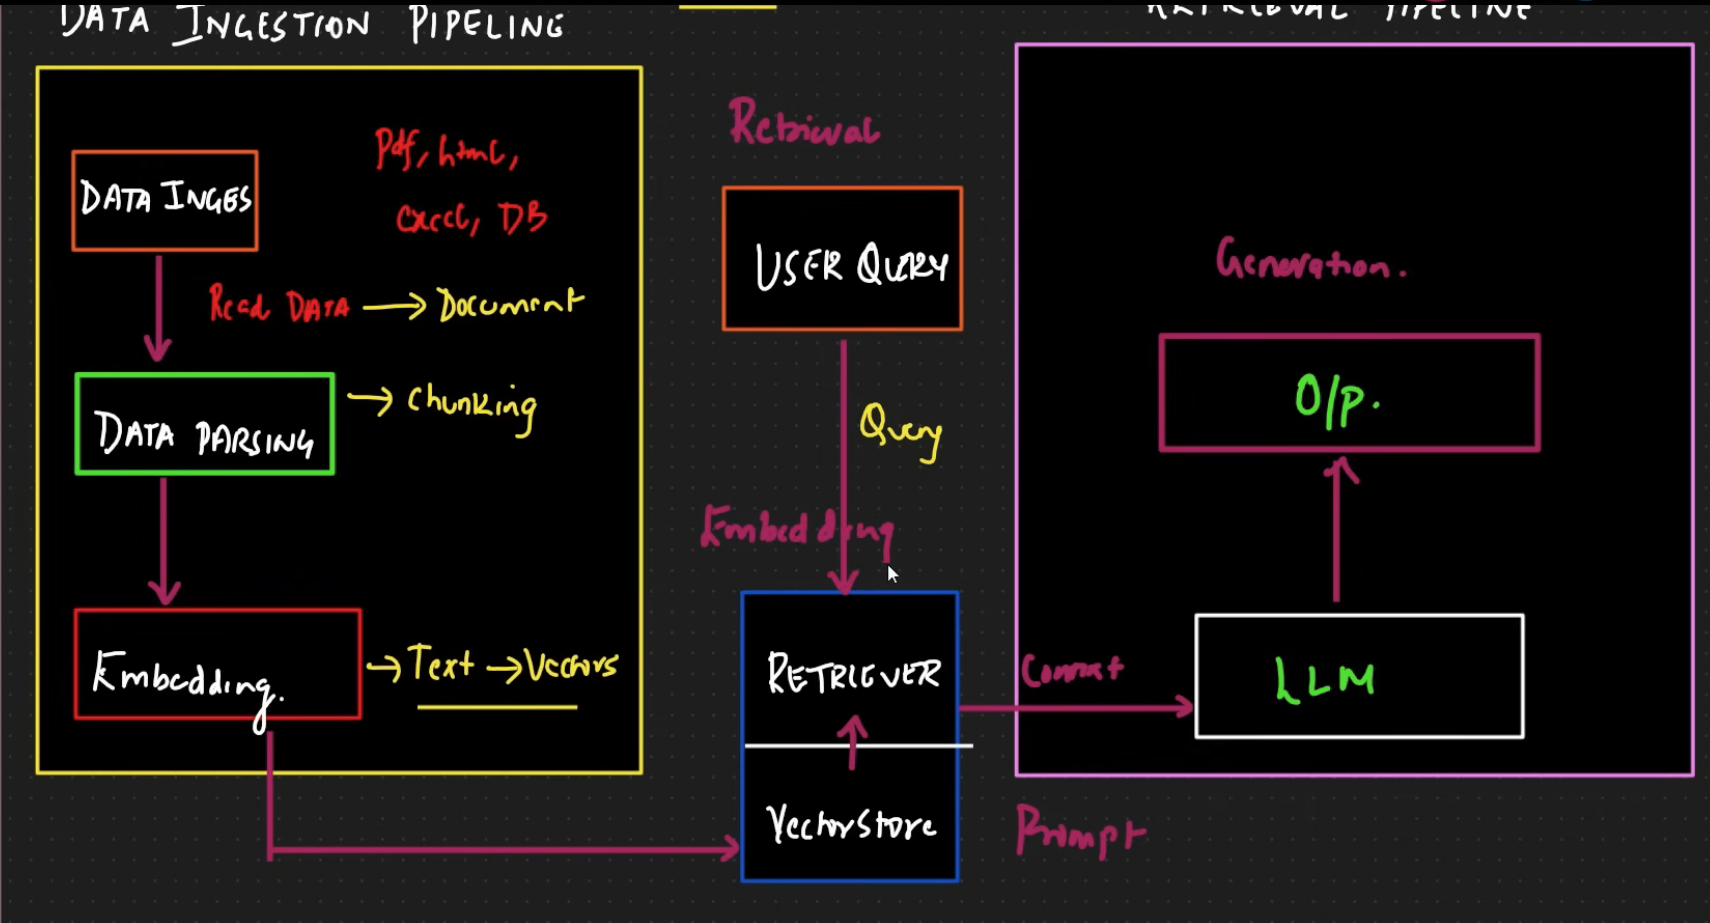

# Retriever Pipeline from VectorStore

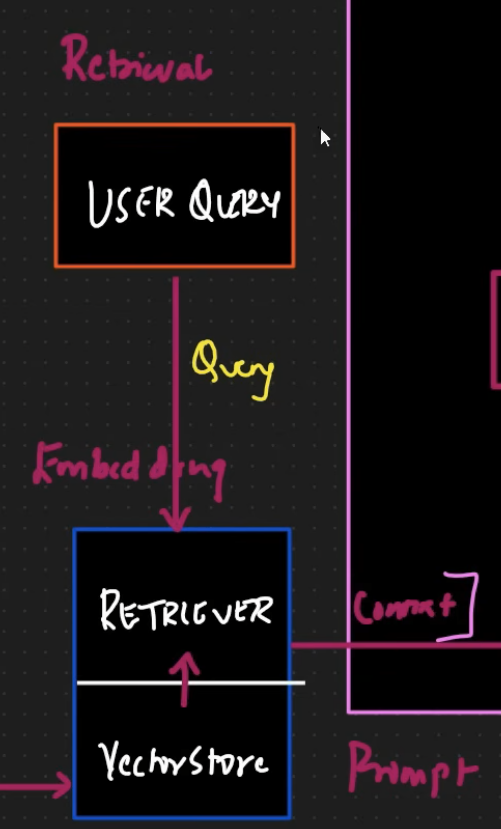

In [14]:
class RAGRetriever:
    """Handles query-based retrieval from vector store
    """

    def __init__(self, vector_store: VectorStore, embedding_manager: EmbeddingManager):
        """Initialize the retriever

        Args:
            vector_store (VectorStore): Vector Store containing document embeddings
            embedding_manager (EmbeddingManager): Manager for generating query embeddings
        """
        self.vector_store = vector_store
        self.embedding_manager = embedding_manager


    def retrieve(self, query: str, top_k: int = 5, score_threshold: float = 0.0) -> List[Dict[str, Any]]:
        """Retrieve relevant documents for a query

        Args:
            query (str): The search query
            top_k (int, optional): Number of top results to return. Defaults to 5.
            score_threshold (float, optional): Minimum similarity score theshold. Defaults to 0.0.

        Returns:
            List[Dict[str, Any]]: List of dictionaries containing retrieved documents and metadata
        """
        print(f"Retrieving documents for query: '{query}")
        print(f"Top K: {top_k}, Score threshold: {score_threshold}")

        # Generate query embedding
        query_embedding = self.embedding_manager.generate_embeddings([query])[0]

        # Search in vector store
        try:
            results = self.vector_store.collection.query(
                    query_embeddings=[query_embedding.tolist()],
                    n_results= top_k
            )

            # Process results
            retrieved_docs = []

            if results["documents"] and results["documents"][0]:
                documents = results["documents"][0]
                metadatas = results["metadatas"][0]
                distances = results["distances"][0]
                ids = results["ids"][0]
            
            for i, (doc_id, document, metadata, distance) in enumerate(zip(ids, documents, metadatas, distances)):
                # Convert distance to similarity score (ChromaDB uses cosine distance)
                similarity_score = 1 - distance
                print("simi:", similarity_score, score_threshold)

                if similarity_score >= score_threshold:
                    retrieved_docs.append(
                        {
                            "id": doc_id,
                            "content": document,
                            "metadata": metadata,
                            "similarity_score": similarity_score,
                            "distance": distance,
                            "rank": i + 1
                        }
                    )

                    print(f"Retrieved {len(retrieved_docs)} documents (after filtering)")
                else:
                    print("No documents found")
                return retrieved_docs
        except Exception as e:
            print(f"Error: {e}")
            raise
        
rag_retriever = RAGRetriever(vector_store=vector_store, embedding_manager=embedding_manager)
rag_retriever

In [15]:
rag_retriever.retrieve("Define the execution tool and prompt template?")

# RAG pipeline completes here

Retrieving documents for query: 'Define the execution tool and prompt template?
Top K: 5, Score threshold: 0.0
Generating embeddings for 1 texts...
Generated embeddings with shape: (1, 384)
simi: -0.1746666431427002 0.0
No documents found


[]

## Integrate VectorDB Context pipeline with LLM OUtput

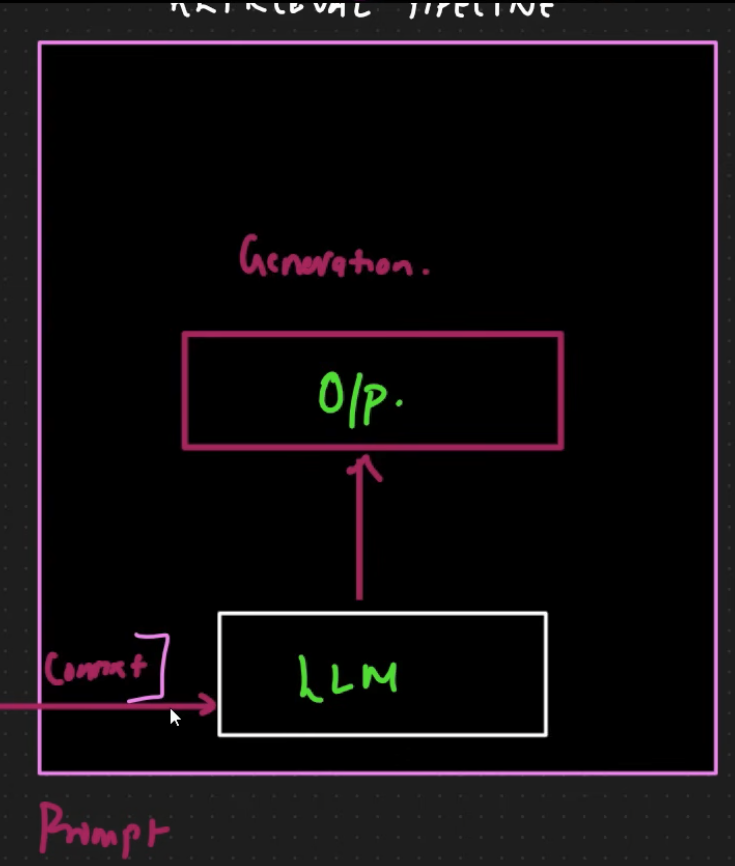

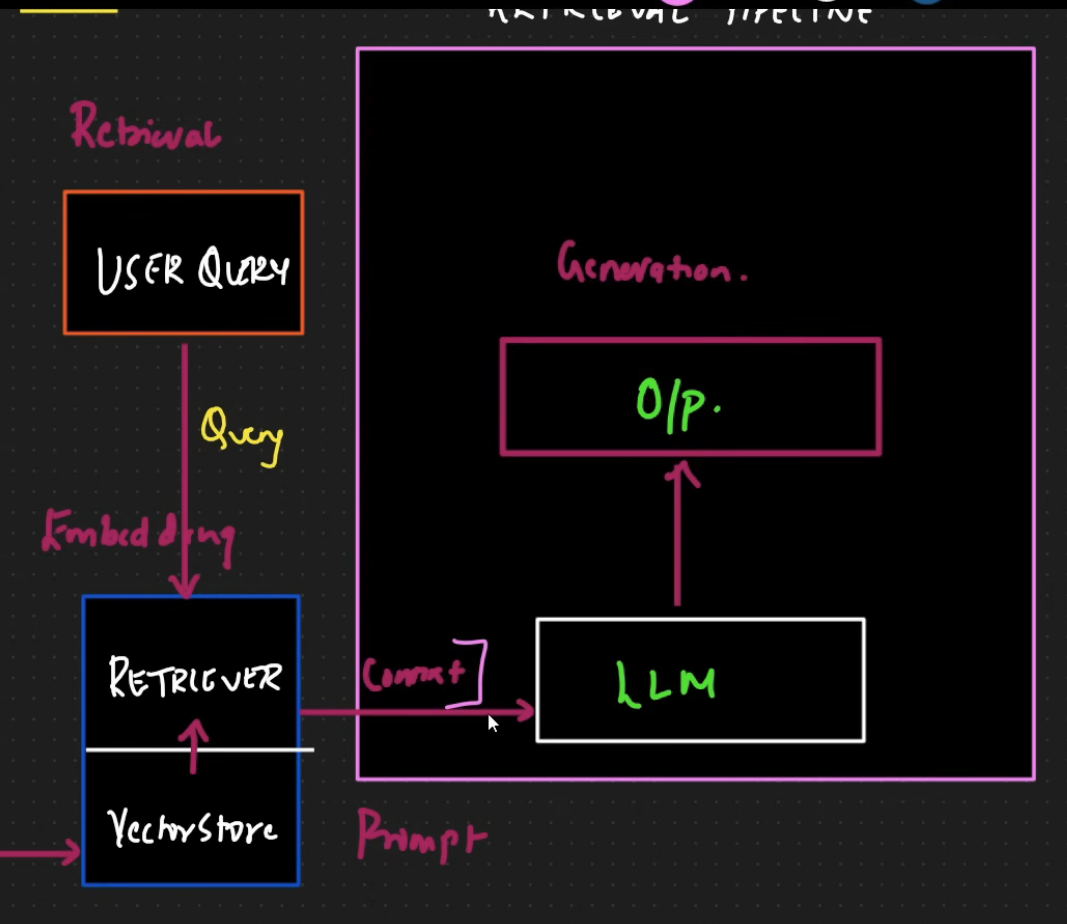

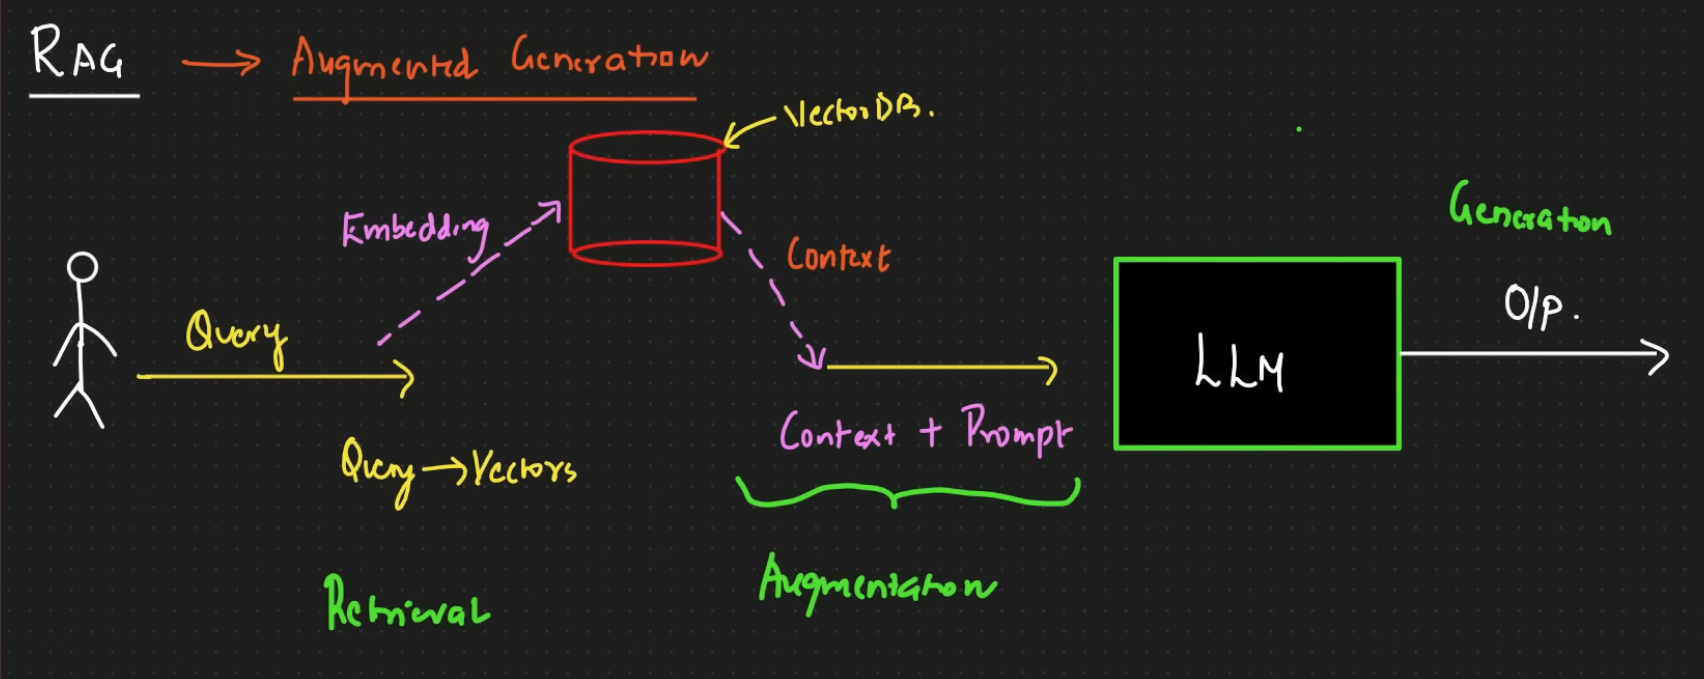

In [16]:
### Simple RAG Pipeline with Groq LLM
from langchain_groq import ChatGroq
import os
from dotenv import load_dotenv
load_dotenv()

groq_api_key = os.getenv("GROQ_API_KEY")

llm = ChatGroq(groq_api_key=groq_api_key, model="llama-3.3-70b-versatile", temperature=0.1, max_tokens=1024)


## 2. Simple RAG function: retrieved contrxt + generated response
def rag_simple(query, retriever, llm, top_k=3):
    """Retrive context"""
    results = retriever.retrieve(query=query, top_k=top_k)
    context: str = "\n\n".join([doc["content"] for doc in results]) if results else ""
    if not context:
        return "No relevant context found"
    
    ## Generate the answer using GROQ LLM
    prompt = f"""
        Using the following context to answer the question concisely.
        Context:
        {context}
        
        Question: {query}
        Answer: 
    """

    response = llm.invoke([prompt.format(context=context, query=query)])
    return response.context


In [17]:
answer = rag_simple("What is the document talking about", rag_retriever, llm)

Retrieving documents for query: 'What is the document talking about
Top K: 3, Score threshold: 0.0
Generating embeddings for 1 texts...
Generated embeddings with shape: (1, 384)
simi: -0.4783257246017456 0.0
No documents found


## Enhanced RAG Pipeline with additional features

In [20]:
def rag_advanced(query, retriever:RAGRetriever, llm, top_k=5, min_score=0.2, return_context=False):
    """RAG pipeline with extra features
    - Returns answer, source, confidence score and optionally full context
    """
    results = retriever.retrieve(query, top_k=top_k, score_threshold=min_score)
    if not results:
        return {"answer": "No relevant context found.", "source": [], "confidence": 0.0, "context": ""}
    
    # Prepare context and sources
    context = "\n\n".join([doc["content"] for doc in results])
    sources = [{
        "source": doc["metadata"].get("source_file", doc["metadata"].get("spirce", "unknown")),
        "page": doc["metadata"].get("page", "unknown"),
        "score": doc["similarity_score"],
        "preview": doc["content"][:300] + "..."
    } for doc in results]
    confidence = max([doc["similarity_score"] for doc in results])

    # Generate answer
    prompt = f"""
        Using the following context to answer the question concisely.
        Context:
        {context}
        
        Question: {query}
        Answer: 
    """
    response = llm.invoke([prompt.format(context=context, query=query)])

    output = {
        "answer": response.content,
        "sources": sources,
        "confidence": confidence
    }
    if return_context:
        output["content"] = context
    return output

# Example usage:
result = rag_advanced("Hard Negative Mining Technqiues", rag_retriever, llm, top_k=3, min_score=0.1, return_context=True)
print("Answer:", result['answer'])
print("Sources:", result['source'])
print("Confidence:", result['confidence'])
print("Context Preview:", result['context'][:300])

Retrieving documents for query: 'Hard Negative Mining Technqiues
Top K: 3, Score threshold: 0.1
Generating embeddings for 1 texts...
Generated embeddings with shape: (1, 384)
simi: -0.8397066593170166 0.1
No documents found
Answer: No relevant context found.
Sources: []
Confidence: 0.0
Context Preview: 


In [18]:
# --- Advanced RAG Pipeline: Streaming, Citations, History, Summarization ---
from typing import List, Dict, Any
import time

class AdvancedRAGPipeline:
    def __init__(self, retriever, llm):
        self.retriever = retriever
        self.llm = llm
        self.history = []  # Store query history

    def query(self, question: str, top_k: int = 5, min_score: float = 0.2, stream: bool = False, summarize: bool = False) -> Dict[str, Any]:
        # Retrieve relevant documents
        results = self.retriever.retrieve(question, top_k=top_k, score_threshold=min_score)
        if not results:
            answer = "No relevant context found."
            sources = []
            context = ""
        else:
            context = "\n\n".join([doc['content'] for doc in results])
            sources = [{
                'source': doc['metadata'].get('source_file', doc['metadata'].get('source', 'unknown')),
                'page': doc['metadata'].get('page', 'unknown'),
                'score': doc['similarity_score'],
                'preview': doc['content'][:120] + '...'
            } for doc in results]
            # Streaming answer simulation
            prompt = f"""Use the following context to answer the question concisely.\nContext:\n{context}\n\nQuestion: {question}\n\nAnswer:"""
            if stream:
                print("Streaming answer:")
                for i in range(0, len(prompt), 80):
                    print(prompt[i:i+80], end='', flush=True)
                    time.sleep(0.05)
                print()
            response = self.llm.invoke([prompt.format(context=context, question=question)])
            answer = response.content

        # Add citations to answer
        citations = [f"[{i+1}] {src['source']} (page {src['page']})" for i, src in enumerate(sources)]
        answer_with_citations = answer + "\n\nCitations:\n" + "\n".join(citations) if citations else answer

        # Optionally summarize answer
        summary = None
        if summarize and answer:
            summary_prompt = f"Summarize the following answer in 2 sentences:\n{answer}"
            summary_resp = self.llm.invoke([summary_prompt])
            summary = summary_resp.content

        # Store query history
        self.history.append({
            'question': question,
            'answer': answer,
            'sources': sources,
            'summary': summary
        })

        return {
            'question': question,
            'answer': answer_with_citations,
            'sources': sources,
            'summary': summary,
            'history': self.history
        }

# Example usage:
adv_rag = AdvancedRAGPipeline(rag_retriever, llm)
result = adv_rag.query("what is attention is all you need", top_k=3, min_score=0.1, stream=True, summarize=True)
print("\nFinal Answer:", result['answer'])
print("Summary:", result['summary'])
print("History:", result['history'][-1])

Retrieving documents for query: 'what is attention is all you need
Top K: 3, Score threshold: 0.1
Generating embeddings for 1 texts...


Generated embeddings with shape: (1, 384)
simi: -0.6655621528625488 0.1
No documents found

Final Answer: No relevant context found.
Summary: There is no text to summarize. The original response indicates that no relevant context was found, providing no information to work with.
History: {'question': 'what is attention is all you need', 'answer': 'No relevant context found.', 'sources': [], 'summary': 'There is no text to summarize. The original response indicates that no relevant context was found, providing no information to work with.'}
